<a href="https://www.kaggle.com/code/khanbabaahamaliiev/notebookd9a2017842?scriptVersionId=355853476" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

Завдання:
Ознайомитись з даними та структурою даних
Створіть доповнення(transform) для тренувальних та тестових даних. посилання
Створіть train_dataset та test_dataset за допомогою ImageFolder
Створіть DataLoader
Візуалізуйте дані
Збережіть kaggle notebook для подальшої роботи

In [1]:
from torchvision.datasets import ImageFolder
from torchvision import transforms
import torch

In [2]:
data_cats = "/kaggle/input/datasets/yapwh1208/cats-breed-dataset/cat_v1"
dataset = ImageFolder(data_cats)

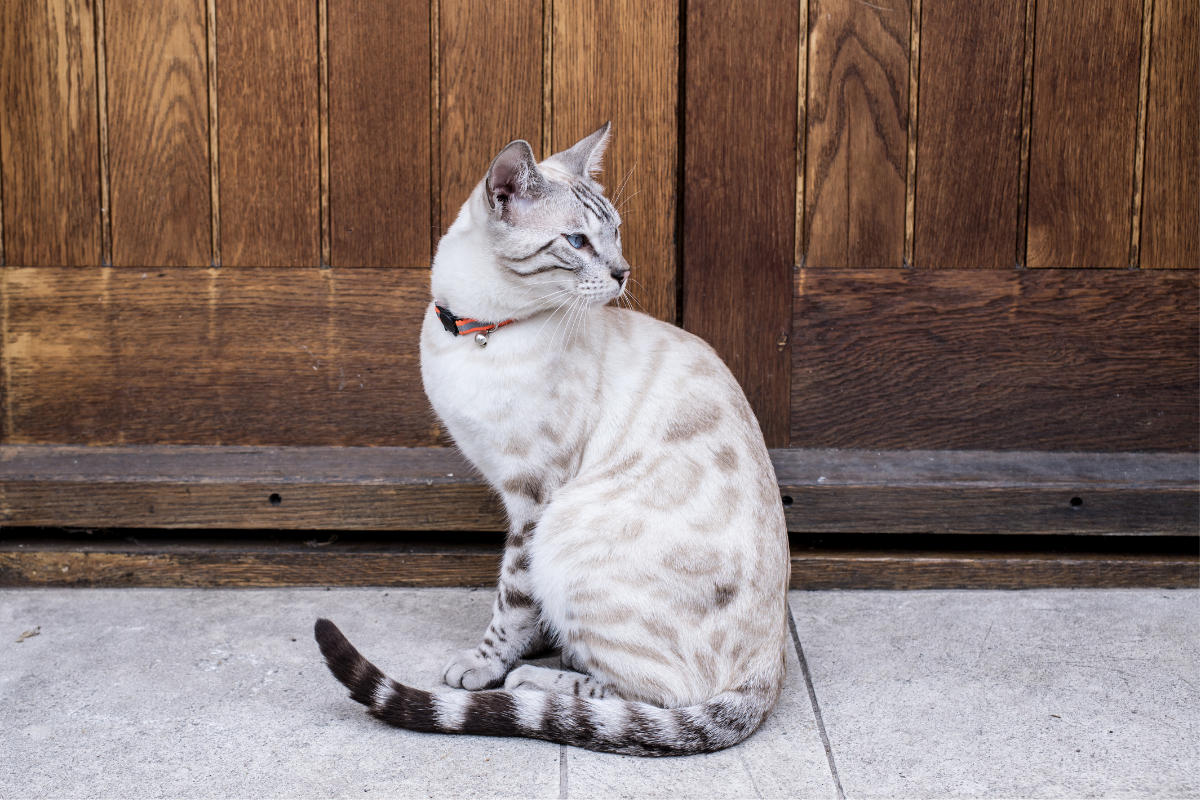

In [3]:
img, label = dataset[100]
img

In [4]:
dataset.classes

['bengal', 'domestic_shorthair', 'maine_coon', 'ragdoll', 'siamese']

In [5]:
train_transformer = transforms.Compose([
       transforms.Resize([128, 128]),
       transforms.RandomHorizontalFlip(p=0.5), 
       transforms.RandomRotation(10),
       transforms.ToTensor()
])

test_transformer = transforms.Compose([
       transforms.Resize([128, 128]),
       transforms.ToTensor()
])

In [6]:
from torch.utils.data import random_split

train_dataset, test_dataset = random_split(dataset, [0.8, 0.2])

In [7]:
len(test_dataset)

190

In [8]:
from torch.utils.data import Dataset

class CatDataset(Dataset):
    def __init__(self, dataset, transformer):
        super().__init__()
        self.dataset = dataset
        self.transformer = transformer

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]

        img_new = self.transformer(img)

        return img_new, label

In [9]:
train_dataset = CatDataset(train_dataset, train_transformer)
test_dataset = CatDataset(test_dataset, test_transformer)

In [10]:
train_dataset[1]

(tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]),
 2)

In [11]:
from torch.utils.data import DataLoader

In [12]:
train_loader = DataLoader(train_dataset, batch_size=100)
test_loader = DataLoader(train_dataset, batch_size=100)

In [13]:
for imgs, labels in train_loader:
    break

In [14]:
imgs.shape

torch.Size([100, 3, 128, 128])

In [15]:
labels

tensor([1, 2, 2, 1, 4, 3, 4, 4, 0, 3, 2, 2, 3, 2, 1, 2, 3, 4, 4, 3, 1, 3, 4, 4,
        2, 4, 2, 2, 3, 3, 2, 3, 4, 4, 3, 2, 0, 3, 4, 4, 4, 4, 2, 4, 4, 0, 4, 2,
        2, 2, 2, 2, 3, 3, 4, 0, 1, 2, 4, 0, 0, 1, 4, 4, 2, 3, 4, 3, 4, 3, 2, 4,
        0, 0, 0, 0, 4, 4, 1, 1, 2, 2, 1, 1, 2, 1, 3, 0, 2, 0, 1, 1, 1, 1, 2, 3,
        3, 3, 2, 1])

Завдання:
На основі train_dataset та test_dataset з попереднього завдання створити train_loader та test_loader

Створити нейромережу:

використайте 2-4 шари
перший шар Flatten
кількість нейронів у шарах має не збільшуватись
використайте функції активації RELU
Документація:
Sequentional
Flatten
Linear
RelU
це треба щоб побачити ймовірності Softmax
Натренуйте нейромережу

створіть функцію помилок CrossEntropyLoss
створіть оптимізатор Adam
розпишіть один крок навчання на тренувальному даталоудері приклад
розпишіть навчання на декілька епох
Змініть алгоритм навчання таким чином щоб можна було зберігати тренувальні помилки

Також збережіть помилки на тестових даних у виведіть їхні графіки

Збережіть kaggle notebook для подальшої роботи

In [19]:
from torch import nn

In [17]:
128 * 128 * 3

49152

Завдання: Змініть структуру нейромережі:

добавте згорткові шари Conv2d з kernel_size=3 та padding='same' добавте MaxPool2d з kernel_size=2 та stride=2 натренуйте заново нейромережу

In [45]:
model = nn.Sequential(
    nn.Conv2d(kernel_size=3, padding='same', out_channels=10, in_channels=3), #10 128 128
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),#10 64 64
    nn.Conv2d(kernel_size=3, padding='same', out_channels=20, in_channels=10), # 20 63 63
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),#20 32 32
    nn.Conv2d(kernel_size=3, padding='same', out_channels=30, in_channels=20), # 30 32 32
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),#30 16 16
    nn.Conv2d(kernel_size=3, padding='same', out_channels=30, in_channels=30), # 30 16 16
    nn.ReLU(),

    nn.Flatten(), 
    nn.Linear(6750, 5)
)


In [43]:
30 * 15 * 15

6750

In [46]:
for X, y in train_loader:
    break

In [47]:
res = model(X)

In [48]:
res.shape

torch.Size([100, 5])

In [57]:
from torch.optim import Adam

loss_fn = nn.CrossEntropyLoss()

optimizer = Adam(
    model.parameters(),
    lr=0.001,)

In [58]:
device = "cuda"

model = model.to(device)

In [56]:
for X_batch, y_batch in train_loader:
    X_batch = X_batch.to(device) 
    y_batch = y_batch.to(device) 

    y_pred = model(X_batch)

    loss = loss_fn(y_pred, y_batch)

    print(loss)

    loss.backward() 
    optimizer.step()
    optimizer.zero_grad()  

KeyboardInterrupt: 

In [59]:
epochs = 20
train_lost = []
test_lost = []

for _ in range(epochs):
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)  
        y_batch = y_batch.to(device)  
    
        y_pred = model(X_batch)
    
        loss = loss_fn(y_pred, y_batch)
    
        print(loss.item())

        train_lost.append(loss.item())
    
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)  
        y_batch = y_batch.to(device)  
    
        y_pred = model(X_batch)
    
        loss = loss_fn(y_pred, y_batch)
    
        print(loss.item())

        test_lost.append(loss.item())
    



        

1.603731632232666
1.6374213695526123
1.6091171503067017
1.6041585206985474
1.594744086265564
1.5969103574752808
1.5812487602233887
1.5930274724960327
1.5795363187789917
1.569097638130188
1.5838632583618164
1.5804229974746704
1.5805842876434326
1.5894198417663574
1.55820894241333
1.5821632146835327
1.5794531106948853
1.5674618482589722
1.5601565837860107
1.5799963474273682
1.5223580598831177
1.543359637260437
1.5108001232147217
1.5145490169525146
1.525235652923584
1.5151852369308472
1.5551296472549438
1.5422537326812744
1.543218731880188
1.5528148412704468
1.4713281393051147
1.514351725578308
1.5256577730178833
1.4810400009155273
1.4590356349945068
1.5751659870147705
1.4357165098190308
1.432629108428955
1.410799264907837
1.4437000751495361
1.4537811279296875
1.4745113849639893
1.5287985801696777
1.4858365058898926
1.5027700662612915
1.4977874755859375
1.4158440828323364
1.4518203735351562
1.4585984945297241
1.412034034729004
1.3932931423187256
1.5459977388381958
1.3571962118148804
1.362

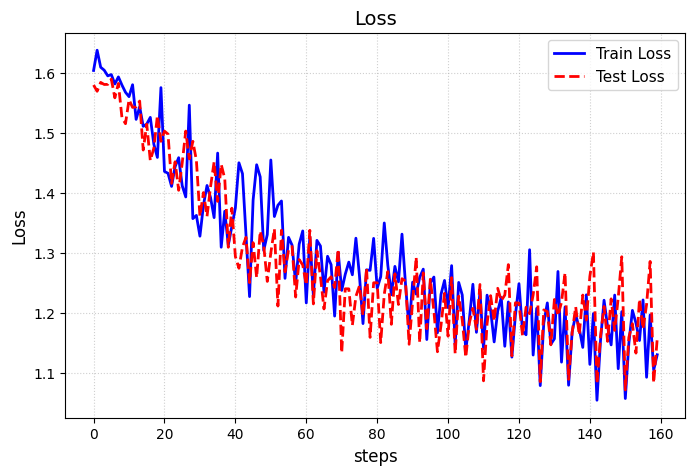

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(train_lost, label='Train Loss', color='blue', linewidth=2)
plt.plot(test_lost, label='Test Loss', color='red', linestyle='--', linewidth=2)

plt.title('Loss', fontsize=14)
plt.xlabel('steps', fontsize=12)
plt.ylabel('Loss', fontsize=12)

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)

plt.show()